In [37]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [204]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "high_grade_glioma"
rd=2
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [193]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 10})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [83]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [205]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [206]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [207]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [208]:
vireo_matrix.head()

,GSM7305261_single-cell,GSM7305262_single-cell,GSM7305263_single-cell,GSM7305264_single-cell,GSM7305265_single-cell,GSM7305266_single-cell,GSM7305267_single-cell,GSM7305268_single-cell,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.286841,0.200048,0.285458,0.281479,0.221499,0.316379,0.195733,0.199398,0.227227,0.196579,0.200596,0.214709,0.203891,0.197720,0.285733,0.299796,0.289216,0.270767
GSM7305243_bulk,0.278593,0.202022,0.284553,0.282367,0.222579,0.315137,0.198283,0.201408,0.227626,0.198711,0.202919,0.215667,0.205681,0.200030,0.285200,0.299691,0.288041,0.271963
GSM7305244_bulk,0.311387,0.227497,0.309964,0.308869,0.250922,0.337543,0.226515,0.230794,0.253102,0.227557,0.230837,0.242278,0.233351,0.228125,0.311665,0.322663,0.313877,0.298991
GSM7305245_bulk,0.319247,0.241193,0.310078,0.316881,0.259560,0.344796,0.238139,0.241463,0.263373,0.238801,0.242549,0.253049,0.244485,0.239808,0.320064,0.332083,0.320783,0.309289
GSM7305246_bulk,0.302355,0.222815,0.300817,0.294415,0.239194,0.326735,0.219233,0.221352,0.245055,0.219441,0.223748,0.234229,0.226047,0.220972,0.302225,0.312715,0.304206,0.289333


In [209]:
vireo_matrix.shape

(18, 18)

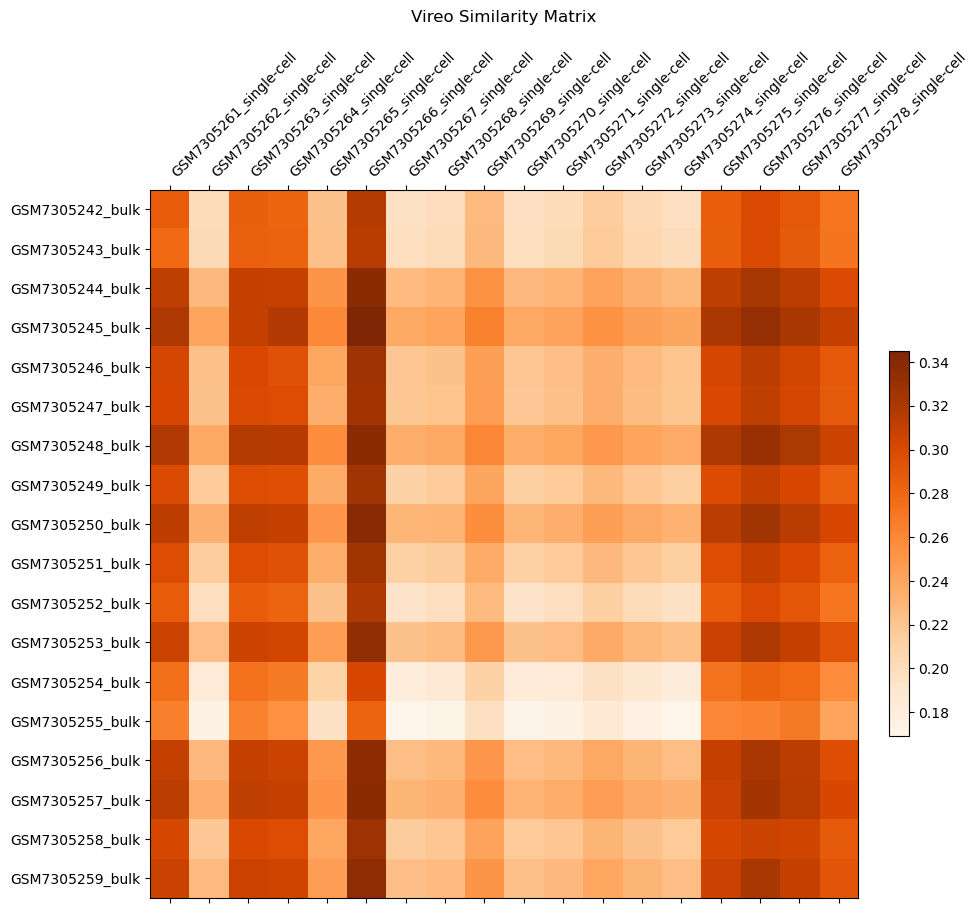

In [210]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

In [73]:
# bulk_vs_singlecell_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

In [26]:
vireo_matches = pd.read_csv(DATA_PATH + f"vireo/{dataset}/matched_samples.csv", index_col=0).reset_index()

In [27]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [28]:
vireo_matches

,sample_id_0,sample_id_1
0,GSM7305261_single-cell,GSM7305243_bulk
1,GSM7305262_single-cell,GSM7305244_bulk
2,GSM7305263_single-cell,GSM7305245_bulk
3,GSM7305264_single-cell,GSM7305246_bulk
4,GSM7305265_single-cell,GSM7305247_bulk
5,GSM7305266_single-cell,GSM7305248_bulk
6,GSM7305267_single-cell,GSM7305249_bulk
7,GSM7305268_single-cell,GSM7305242_bulk
8,GSM7305269_single-cell,GSM7305251_bulk
9,GSM7305270_single-cell,GSM7305252_bulk


# NGSCheckmate

In [156]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [157]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".vcf", "").replace("ds.", "").replace("_individual_variants", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [158]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7305242_bulk,matched,GSM7305243_bulk,1.0,235.29
GSM7305242_bulk,matched,GSM7305244_bulk,1.0,243.12
GSM7305242_bulk,matched,GSM7305245_bulk,1.0,241.02
GSM7305242_bulk,matched,GSM7305246_bulk,1.0,252.22
GSM7305242_bulk,matched,GSM7305247_bulk,1.0,246.74


In [159]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [160]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [161]:
ngscheckmate_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,2.3529,2.4312,2.4102,2.5222,2.4674,2.5222,2.5222,2.5222,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305243_bulk,2.3529,NaN,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,2.3529,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305244_bulk,2.4312,2.3529,NaN,2.4102,2.4312,2.4312,2.4312,2.4312,2.4312,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305245_bulk,2.4102,2.3529,2.4102,NaN,2.4102,2.4102,2.4102,2.4102,2.4102,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421
GSM7305246_bulk,2.5222,2.3529,2.4312,2.4102,NaN,2.4674,2.5273,2.5273,2.5273,2.3828,...,0.5247,0.6214,0.3867,0.5686,0.4386,0.4363,0.806,0.6338,1.2371,0.6421


In [131]:
# all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

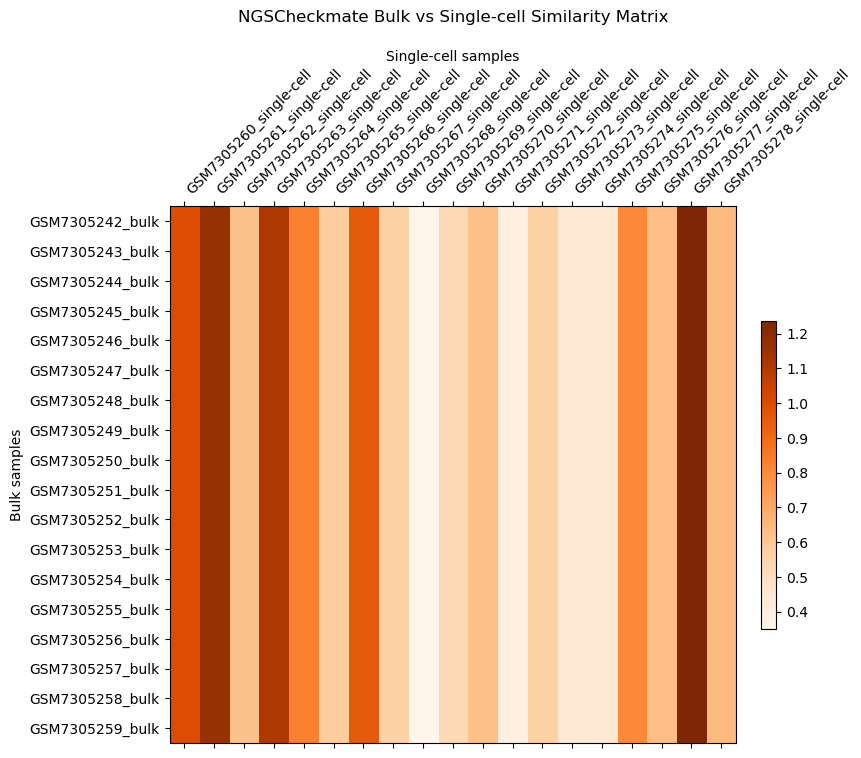

In [162]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [163]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [164]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("ds.", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [165]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM7305242_bulk,GSM7305260_single-cell,0.038,223932
GSM7305242_bulk,GSM7305261_single-cell,0.032,187101
GSM7305242_bulk,GSM7305262_single-cell,0.014,128680
GSM7305242_bulk,GSM7305263_single-cell,0.031,187049
GSM7305242_bulk,GSM7305264_single-cell,0.022,195404


In [166]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [167]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [168]:
hysys_matrix.head()

,GSM7305260_single-cell,GSM7305261_single-cell,GSM7305262_single-cell,GSM7305263_single-cell,GSM7305264_single-cell,GSM7305265_single-cell,GSM7305266_single-cell,GSM7305267_single-cell,GSM7305268_single-cell,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.038,0.032,0.014,0.031,0.022,0.020,0.024,0.013,0.011,0.018,0.017,0.012,0.018,0.012,0.012,0.025,0.018,0.034,0.018
GSM7305243_bulk,0.036,0.050,0.017,0.037,0.024,0.027,0.025,0.017,0.014,0.022,0.020,0.014,0.021,0.015,0.015,0.030,0.018,0.038,0.020
GSM7305244_bulk,0.036,0.036,0.021,0.037,0.023,0.024,0.027,0.016,0.012,0.021,0.019,0.014,0.020,0.015,0.014,0.027,0.020,0.037,0.020
GSM7305245_bulk,0.040,0.038,0.017,0.051,0.026,0.026,0.029,0.015,0.013,0.022,0.018,0.014,0.020,0.015,0.013,0.029,0.020,0.040,0.021
GSM7305246_bulk,0.037,0.036,0.015,0.036,0.029,0.024,0.027,0.014,0.012,0.020,0.017,0.013,0.020,0.013,0.013,0.029,0.020,0.038,0.021


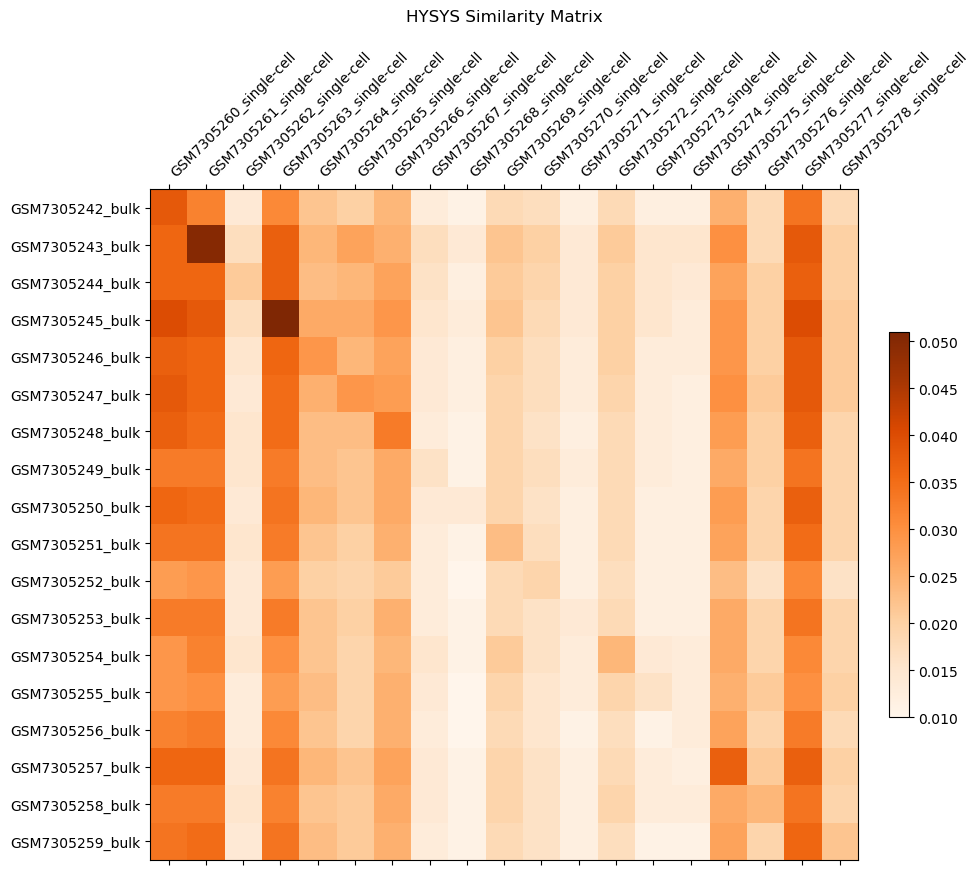

In [169]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

In [140]:
# bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [170]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [171]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [172]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7305273_single-cell,GSM7305273_single-cell,16.710400,EXPECTED_MATCH
1,GSM7305273_single-cell,GSM7305264_single-cell,-3.771864,EXPECTED_MISMATCH
2,GSM7305273_single-cell,GSM7305250_bulk,-4.595718,EXPECTED_MISMATCH
3,GSM7305273_single-cell,GSM7305266_single-cell,-14.557913,EXPECTED_MISMATCH
4,GSM7305273_single-cell,GSM7305257_bulk,-1.938815,EXPECTED_MISMATCH


In [173]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [174]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [175]:
fingerprints_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,176.757746,-56.325774,-70.129482,-44.733566,-22.350935,-38.258889,-74.475824,-51.247964,-54.002335,-40.407448,...,-2.920249,-1.909680,-3.689765,-8.143261,-3.729494,-0.868439,-11.470287,-17.640312,-6.911822,-6.026519
GSM7305243_bulk,-56.325774,183.212203,-34.512472,-58.458086,-43.195448,-72.194752,-74.583503,-56.259000,-67.567351,-44.213752,...,-8.767173,-6.343010,-6.905815,-8.771019,-3.415871,-4.479696,-23.977338,-15.219155,-13.069800,-6.856744
GSM7305244_bulk,-70.129482,-34.512472,233.217349,-93.477372,-59.129597,-67.222488,-56.630703,-68.668395,-99.825325,-71.921531,...,-4.827577,-3.371937,-1.873712,-2.403171,-6.055135,-5.564697,-14.627555,-21.705936,-10.215477,-6.010229
GSM7305245_bulk,-44.733566,-58.458086,-93.477372,272.828933,-51.657156,-50.877956,-130.356055,-66.387021,-97.490502,-48.713881,...,-11.548155,0.282157,-5.019313,-0.086428,-4.105136,-0.324088,-18.851721,-13.057030,-9.056541,-13.494638
GSM7305246_bulk,-22.350935,-43.195448,-59.129597,-51.657156,213.092782,-34.299749,-51.141093,-41.007179,-54.470174,-42.313766,...,-4.108299,-6.034705,-3.320115,-3.428074,-4.508520,-1.279984,-28.735335,-39.443069,-13.871475,-15.757328


In [176]:
# all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

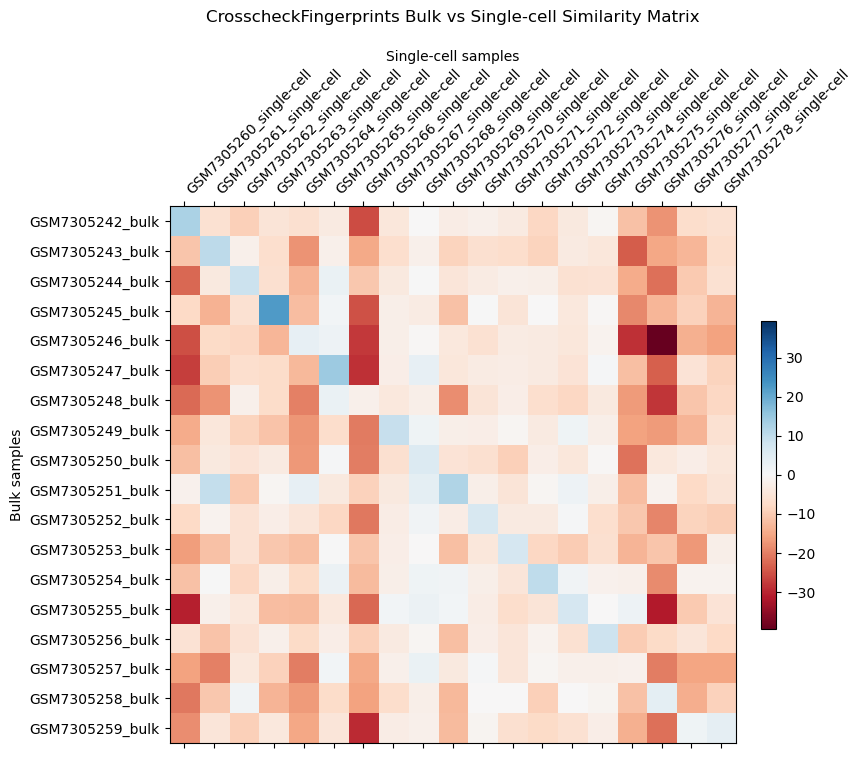

In [177]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [352]:
fingerprints_df["RESULT"].value_counts()

RESULT
EXPECTED_MISMATCH    4360
EXPECTED_MATCH         67
UNEXPECTED_MATCH       62
Name: count, dtype: int64

In [353]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [354]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [355]:
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("polyA") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("polyA"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,197.938691,UNEXPECTED_MATCH
1,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,186.372326,UNEXPECTED_MATCH
2,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,204.709169,UNEXPECTED_MATCH
3,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,221.965748,UNEXPECTED_MATCH
4,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,182.191976,UNEXPECTED_MATCH
5,HGSOC-2186_bulk_chunk_ribo,HGSOC-2186_bulk_diss_polyA,205.165566,UNEXPECTED_MATCH
6,HGSOC-2202_bulk_chunk_ribo,HGSOC-2202_bulk_diss_polyA,227.722145,UNEXPECTED_MATCH
7,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_diss_polyA,195.143683,UNEXPECTED_MATCH
8,HGSOC-2209_bulk_diss_polyA,HGSOC-2526_bulk_chunk_ribo,193.867424,UNEXPECTED_MATCH
9,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA,244.463959,UNEXPECTED_MATCH


# BAMixChecker

In [66]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [67]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [68]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7305243_bulk,GSM7305270_single-cell,0.0,Unmatched
GSM7305243_bulk,GSM7305249_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305248_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305253_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305252_bulk,0.0,Unmatched


In [69]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [70]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [71]:
bamixchecker_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305243_bulk,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305244_bulk,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305245_bulk,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305246_bulk,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

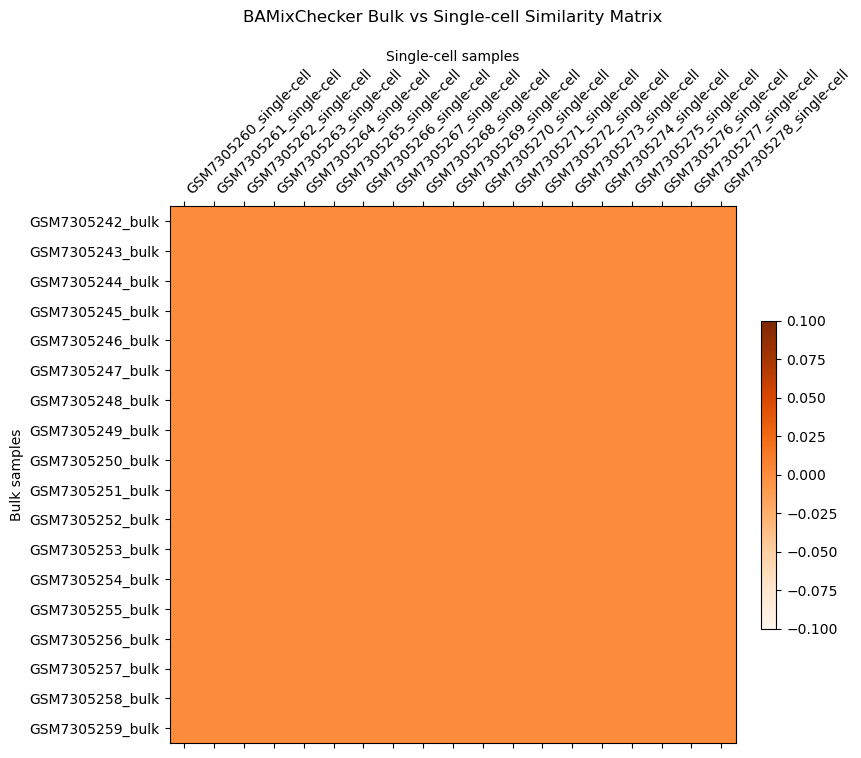

In [73]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

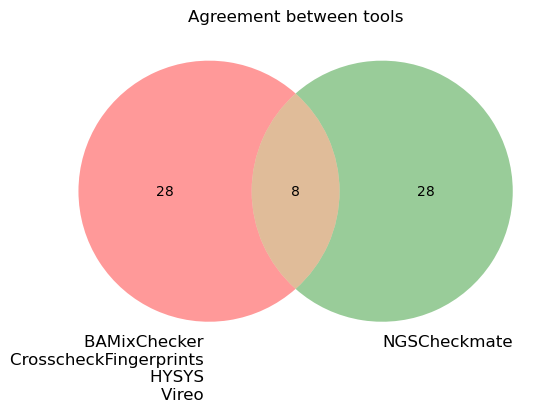

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300